# K Means Clustering

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs ## for creating clustered looking data
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(
    n_samples=1000,
    centers=3, ## henerally meaning 3 clusters
    n_features=2, ## This is better for visualization
    random_state=10
)
    

In [3]:
X

array([[ 4.56889035, -9.9492391 ],
       [ 2.35388502,  3.51466401],
       [-0.01750156, -6.05038477],
       ...,
       [ 4.89123569,  4.86995972],
       [ 1.09272697,  4.04641343],
       [ 0.97077866, -4.8289551 ]])

In [4]:
y[:5]

array([0, 1, 2, 2, 1])

The clustering will be done based on the X data. We are just going to use the y data to direct us

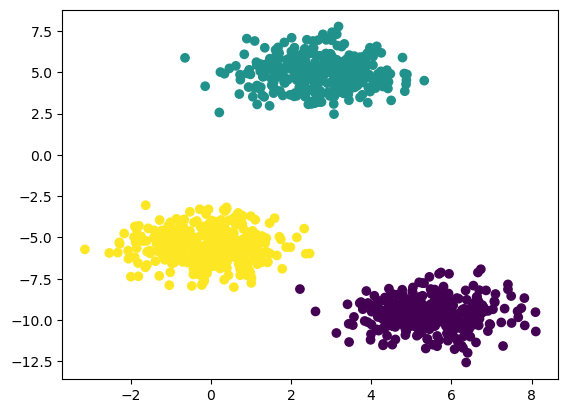

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

We can see clearly that it will form 3 clusters but we will apply ELBOW METHOD to know the k value because we will have more complicated situations compared to this.

In [6]:
## Statndardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.33,random_state=42)

In [8]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test) ## remember to prevent data_leakage

In [9]:
from sklearn.cluster import KMeans

In [10]:
## Elbow method to select k value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++') ## refer to note for why we use kmeans++
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
    
wcss

[1339.999999999999,
 571.3457849074312,
 119.48468984536365,
 97.36022198937229,
 76.85433608819247,
 53.920699844184234,
 47.161250700007116,
 41.47495810816104,
 39.381674035554155,
 32.62038070693853]

You can see that the wcss values decreases as the kvalue increased. We can plot this aganst the kvalues to get the Elbow curve

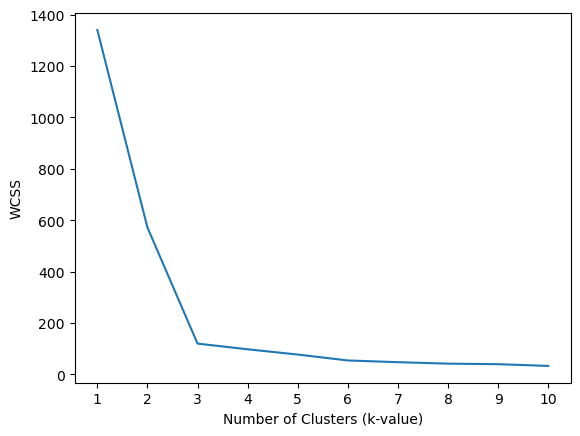

In [11]:
## plot ELBOW CURVE
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel('Number of Clusters (k-value)')
plt.ylabel('WCSS')
plt.show()

You can see the elbow curve is on k=3. So it will generate 3 clusters as the best clusters. Which is very accurate based on eye test.

In [12]:
kmeans=KMeans(n_clusters=3,init='k-means++')

In [13]:
## predict the training data
kmeans.fit_predict(X_train_scaled)

array([2, 0, 2, 0, 0, 1, 1, 2, 0, 2, 1, 1, 1, 0, 1, 1, 2, 2, 2, 1, 1, 1,
       1, 2, 2, 1, 1, 1, 2, 2, 0, 2, 1, 2, 2, 0, 2, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 2, 1, 1, 0, 1, 1, 2, 1, 0, 2, 0, 2, 2, 1, 0, 0, 0, 1,
       0, 0, 1, 2, 2, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 2, 2, 2, 0, 1, 2,
       1, 0, 0, 2, 0, 2, 0, 1, 1, 1, 2, 1, 0, 1, 2, 2, 0, 0, 0, 2, 1, 2,
       0, 0, 1, 1, 0, 2, 2, 1, 1, 2, 1, 0, 1, 0, 1, 2, 1, 1, 1, 1, 1, 2,
       1, 1, 1, 1, 1, 0, 2, 0, 1, 0, 2, 2, 0, 1, 0, 2, 2, 2, 2, 1, 2, 0,
       2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 0, 2, 1, 0, 0, 2, 0, 2, 2, 2, 1,
       2, 2, 2, 2, 1, 1, 0, 1, 1, 2, 0, 0, 2, 1, 1, 2, 1, 0, 0, 1, 0, 1,
       0, 2, 2, 2, 0, 2, 0, 0, 1, 1, 0, 0, 1, 2, 0, 0, 1, 0, 2, 2, 2, 2,
       2, 1, 0, 0, 0, 2, 1, 2, 1, 2, 0, 1, 2, 0, 1, 0, 2, 0, 2, 2, 1, 0,
       1, 0, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 1, 2, 0, 2, 2, 1, 2,
       1, 1, 0, 2, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 2, 0,
       0, 2, 2, 2, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 2,

In [14]:
## Get y_pred with test data
y_pred=kmeans.predict(X_test_scaled)

In [15]:
y_pred

array([1, 0, 0, 2, 0, 1, 1, 2, 1, 1, 0, 0, 2, 1, 2, 1, 0, 1, 0, 1, 0, 0,
       1, 2, 2, 1, 1, 1, 2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 0, 2, 0, 2, 1, 1,
       1, 2, 1, 2, 1, 2, 1, 0, 0, 2, 1, 0, 2, 0, 1, 0, 1, 2, 2, 1, 2, 0,
       1, 2, 2, 1, 2, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 0, 1, 1, 2, 2, 1,
       0, 1, 1, 2, 2, 2, 0, 2, 0, 1, 2, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       1, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 0, 2, 0, 2, 2, 0, 2, 0, 1, 1, 0,
       0, 1, 1, 1, 0, 2, 2, 1, 0, 1, 2, 2, 2, 1, 0, 0, 0, 2, 2, 2, 1, 2,
       0, 0, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 0, 2, 0, 0, 1, 0, 1, 1, 0, 1,
       2, 2, 0, 0, 1, 1, 0, 0, 1, 0, 1, 2, 2, 0, 1, 1, 2, 1, 2, 2, 0, 2,
       2, 0, 0, 2, 0, 0, 1, 1, 2, 0, 1, 0, 0, 2, 1, 2, 0, 1, 1, 2, 0, 0,
       0, 2, 2, 0, 2, 1, 2, 0, 1, 1, 0, 0, 2, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 2, 1, 1, 1, 0, 2, 0, 2, 0, 0, 1, 1, 0, 1, 2, 0, 1, 0, 2, 0, 1,
       0, 1, 0, 0, 1, 2, 2, 1, 0, 1, 1, 1, 2, 0, 1, 2, 0, 1, 1, 1, 2, 2,
       1, 2, 2, 2, 1, 2, 1, 1, 0, 1, 0, 2, 1, 2, 2,

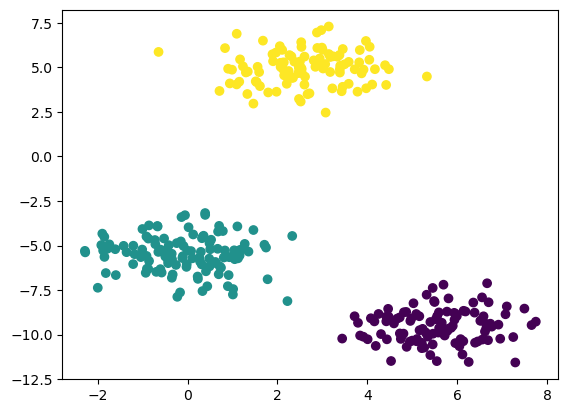

In [16]:
## plot test data to view the cluster
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

Later we can check the accuracy and classification report.

Sometimes the k value might not be easily identified from the Elbow curve because of some instability it can get complex. Then we have to **VALIDATE** the kvalue. There are two ways to do this:

1. Knee Locator
2. Slhouette Scoring

In [19]:
## Validating the k value
## Knee Locator

## install kneed
!pip install kneed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from kneed import KneeLocator

In [24]:
kl=KneeLocator(range(1,11),wcss, curve='convex',direction='decreasing')
kl.elbow

3

You can see that the eye test was accurate, the best k-value is 3

In [25]:
## Silhouette score
from sklearn.metrics import silhouette_score

In [30]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

silhouette_coefficients

[0.5842458853138647,
 0.7577303811282187,
 0.6394655896223154,
 0.6124568476529558,
 0.5119572788463516,
 0.42176486585793627,
 0.40518972356789634,
 0.40247611286594487,
 0.3772744031662541]

Text(0.5, 1.0, 'Silhouette Score')

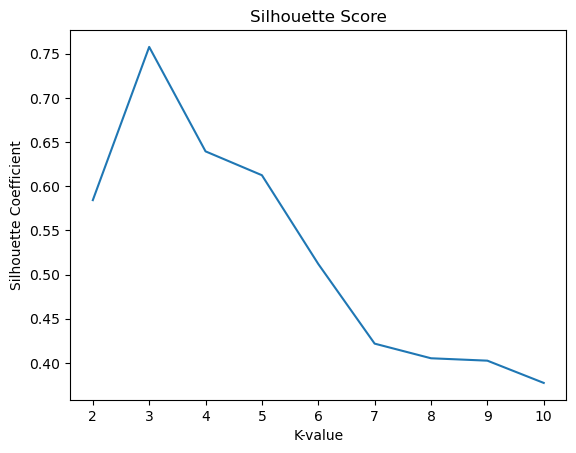

In [32]:
## Visualize with a plot
plt.plot(range(2,11),silhouette_coefficients)
plt.xlabel('K-value')
plt.ylabel('Silhouette Coefficient')
plt.title('Silhouette Score')

Based on the silhoutte score the best score is that of k-value = 3. There for a k value of 3 is the best for this custering

### Important Note

We used kmeans to identify clusters in the data. Now it correctly identified 3 clusters which aligns with the ylabels (0,1,2). The problem is the kmeans model labels the clusters itself which might not align with what in the ylabel. This is a subtle issue that can mislead you when checking for accuracy of the model. Recall ylabel has (0,1,2) but kmeans might have labelled 0 as cluster 1, 1 as cluster 0 and 2 as cluster 2 (which will be correct but 0 and 1 are mixed up). So in this section we will see how to handle this issue.

#### Important practical point

If you already have reliable labels (y = 0, 1, 2) and your goal is to predict those labels for new data, K-Means is usually not the best tool. A supervised classifier such as:

Logistic Regression
Random Forest
XGBoost
Support Vector Machine

will generally perform better because they learn directly from the labels.

K-Means is most useful when labels are unavailable and you're trying to discover natural groupings in the data. Once labels exist, supervised learning is usually the preferred approach.

In [33]:
## lets train the model again with the best kvalue
kmeans=KMeans(n_clusters=3,init='k-means++')

In [34]:
kmeans.fit(X_train_scaled)

KMeans(n_clusters=3)

In [52]:
## Lets view the kmeans labels

import pandas as pd

y_train_pred=kmeans.predict(X_train_scaled)
y_test_pred=kmeans.predict(X_test_scaled)

# df = pd.DataFrame({
#     'cluster': kmeans.labels_,
#     'label': y_train
# }) ## This is still valid for the training label

df_train_pred = pd.DataFrame({
    'cluster': y_train_pred,
    'label': y_train
})

df_test_pred = pd.DataFrame({
    'cluster': y_test_pred,
    'label': y_test
})

print(pd.crosstab(df_train_pred['cluster'], df_train_pred['label']))
print(pd.crosstab(df_test_pred ['cluster'], df_test_pred ['label']))

label      0    1    2
cluster               
0        224    0    0
1          0    0  216
2          0  230    0
label      0    1    2
cluster               
0        109    0    0
1          1    0  117
2          0  103    0


This tells you that the kmeans labels are not in line with our ylabel. the clustering are very accurate but labels do not align. 2 is 1 and 1 is 2. We have to adjust the label for better correctness

In [53]:
cluster_to_label = {
    0: 0,
    1: 2,
    2: 1
}

In [54]:
## adjust the predicted values
y_train_pred_adjust_to_k_labels = []
y_test_pred_adjust_to_k_labels = []

for cluster in y_train_pred:
    predicted_label = cluster_to_label[cluster]
    y_train_pred_adjust_to_k_labels.append(predicted_label)

for cluster in y_test_pred:
    predicted_label2 = cluster_to_label[cluster]
    y_test_pred_adjust_to_k_labels.append(predicted_label2)


In [57]:
## Inspect again
df_train_pred = pd.DataFrame({
    'cluster': y_train_pred_adjust_to_k_labels,
    'label': y_train
})

df_test_pred = pd.DataFrame({
    'cluster': y_test_pred_adjust_to_k_labels,
    'label': y_test
})

print(pd.crosstab(df_train_pred['cluster'], df_train_pred['label']))
print()
print(pd.crosstab(df_test_pred ['cluster'], df_test_pred ['label']))

label      0    1    2
cluster               
0        224    0    0
1          0  230    0
2          0    0  216

label      0    1    2
cluster               
0        109    0    0
1          0  103    0
2          1    0  117


It has been successfully adjusted. We will try to see the performance. **Please note we are only trying this out for inquiry only. It is not advisable to use Kmeans for labelled data. This is just experimental and to learn how to do clustering**

In [59]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score

# Training set performance
model_train_accuracy=accuracy_score(y_train,y_train_pred_adjust_to_k_labels)
model_train_f1=f1_score(y_train,y_train_pred_adjust_to_k_labels, average='weighted')
model_train_precision=precision_score(y_train,y_train_pred_adjust_to_k_labels, average='weighted')
model_train_recall=recall_score(y_train,y_train_pred_adjust_to_k_labels,average='weighted')
# model_train_rocauc_score=roc_auc_score(y_train,y_train_pred_adjust_to_k_labels) ## This works well for binary classification. 

# Testing set performance
model_test_accuracy=accuracy_score(y_test,y_test_pred_adjust_to_k_labels)
model_test_f1=f1_score(y_test,y_test_pred_adjust_to_k_labels, average='weighted')
model_test_precision=precision_score(y_test,y_test_pred_adjust_to_k_labels,average='weighted')
model_test_recall=recall_score(y_test,y_test_pred_adjust_to_k_labels,average='weighted')
# model_test_rocauc_score=roc_auc_score(y_test,y_test_pred_adjust_to_k_labels)

print('Kmeans clustering performance')

print('Model performance for Training set')
print('- Accuracy: {:.4f}'.format(model_train_accuracy))
print('- F1 score: {:.4f}'.format(model_train_f1))
print('- Precision: {:.4f}'.format(model_train_precision))
print('- Recall: {:.4f}'.format(model_train_recall))

print('-----------------------------------')

print('Model performance for Test set')
print('-Accuracy: {:.4f}'.format(model_test_accuracy))
print('- F1 score: {:.4f}'.format(model_test_f1))
print('- Precision: {:.4f}'.format(model_test_precision))
print('- Recall: {:.4f}'.format(model_test_recall))

print('='*35)
print('\n')

Kmeans clustering performance
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
-----------------------------------
Model performance for Test set
-Accuracy: 0.9970
- F1 score: 0.9970
- Precision: 0.9970
- Recall: 0.9970




In [60]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_test_pred_adjust_to_k_labels))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       110
           1       1.00      1.00      1.00       103
           2       0.99      1.00      1.00       117

    accuracy                           1.00       330
   macro avg       1.00      1.00      1.00       330
weighted avg       1.00      1.00      1.00       330

